<!-- bootcamp-header: generated by tools/build_headers.py, edit the README timetable instead -->
# Solutions: pandas

Worked solutions to the exercises in [`13_EX_Pandas.ipynb`](https://github.com/mikekestemont/dtaantwerp26-27.github.io/blob/DTA_Bootcamp_2026_students/exercises/questions/13_EX_Pandas.ipynb), which go with the session [`13_W3_Wed_Pandas.ipynb`](https://github.com/mikekestemont/dtaantwerp26-27.github.io/blob/DTA_Bootcamp_2026_students/notebooks/13_W3_Wed_Pandas.ipynb).  

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mikekestemont/dtaantwerp26-27.github.io/blob/DTA_Bootcamp_2026_students/exercises/solutions/13_SOL_Pandas.ipynb)

In [ ]:
# Run this cell only if you are working on Google Colab: it downloads the course
# material (notebooks and data) so that the file paths in this notebook work.
# On your own computer you can skip it.
!git clone --quiet --depth 1 --branch DTA_Bootcamp_2026_students https://github.com/mikekestemont/dtaantwerp26-27.github.io.git bootcamp
%cd bootcamp/exercises/solutions

Every exercise is followed by one possible solution (sometimes two). Other correct solutions exist: what matters is that yours works and that you understand why.

## Core exercises

### 1. Load and inspect (basic)

Import `pandas`, load `screenplays.csv` into `df` and answer with one line each: how many rows and columns; the names of the columns; the first three rows; the number of missing values per column.

In [1]:
import pandas as pd

df = pd.read_csv('../../data/screenplays.csv')

print(df.shape)
print(list(df.columns))
print(df.head(3))
print(df.isna().sum())

(23042, 9)
['title', 'release_year', 'character', 'gender', 'words', 'proportion_of_dialogue', 'age', 'gross', 'script_id']
                     title  release_year     character gender  words  \
0              Pain & Gain          2013   Daniel Lugo    man   2570   
1                    Shrek          2001  Magic Mirror    man    588   
2  Airplane II: The Sequel          1982        Kramer    man    382   

   proportion_of_dialogue   age  gross  script_id  
0                0.357143  42.0   53.0       7706  
1                0.028635   NaN  411.0       3331  
2                0.065389   NaN    NaN        650  
title                        0
release_year                 0
character                    0
gender                       0
words                        0
proportion_of_dialogue       0
age                       4782
gross                     3659
script_id                    0
dtype: int64


### 2. One column (basic)

Select the `words` column and print its mean, median and maximum, rounded to one decimal. How many *different* film titles are there (`.nunique()` on `title`), and how many different `script_id`s? Why do the two differ?

In [2]:
words = df['words']
print(round(words.mean(), 1), round(words.median(), 1), round(words.max(), 1))
print(df['title'].nunique(), df['script_id'].nunique())
# Some titles were filmed more than once (King Kong, Halloween, ...): same title, different script.

908.0 396.0 28102
1994 2000


### 3. Who? (standard)

Print the character (and film) with the most words, and the film with the highest gross (`.idxmax()` with `.loc[]`). Then show the three *oldest* actors with character, title and age, using `.sort_values()`. What is wrong with what you see, and what would you do about it?

In [3]:
most = df['words'].idxmax()
print(df.loc[most, 'character'], df.loc[most, 'title'])
print(df.loc[df['gross'].idxmax(), 'title'])
print(df.sort_values('age', ascending=False)[['character', 'title', 'age']].head(3))
# Ages of 2007 and 2009 are years that ended up in the age column by mistake. Before using the
# column, drop or ignore the impossible values, for instance with a filter df[df['age'] < 100].

Jim JFK
Star Wars: Episode IV - A New Hope
             character          title     age
19193  Margaret Sulliv        Case 39  2009.0
3507              Bull  Into the Wild  2007.0
11129  Captain Ramirez     Borderland  2007.0


### 4. Filters (standard)

With boolean masks: how many characters appear in films released in 1939? How many women speak more than 5,000 words? How many characters are in films from before 1935 *or* from 2015? How many different titles contain the word *King*?

In [4]:
print(len(df[df['release_year'] == 1939]))
print(len(df[(df['gender'] == 'woman') & (df['words'] > 5000)]))
print(len(df[(df['release_year'] < 1935) | (df['release_year'] == 2015)]))
print(df[df['title'].str.contains('King')]['title'].nunique())

44
114
760
17


### 5. Counts and shares (standard)

How many characters per gender (`.value_counts()`)? What share of all characters are women (the mean of a mask)? What share of the characters with more than 2,000 words are women (filter first)?

In [5]:
print(df['gender'].value_counts())
print(round((df['gender'] == 'woman').mean(), 3))
print(round((df[df['words'] > 2000]['gender'] == 'woman').mean(), 3))

gender
man      16131
woman     6911
Name: count, dtype: int64
0.3
0.27


### 6. Groups (standard)

With `groupby()`: the average age per gender (the impossible ages will barely move the average, but you may filter them out first); the average share of dialogue (`proportion_of_dialogue`) per gender; the number of characters per release year for 2010 to 2015 (`.size()`, then `.loc[2010:2015]` on the result); the title with the most characters.

In [6]:
clean = df[df['age'] < 100]
print(clean.groupby('gender')['age'].mean().round(1))
print(df.groupby('gender')['proportion_of_dialogue'].mean().round(3))
print(df.groupby('release_year').size().loc[2010:2015])
print(df.groupby('title').size().idxmax())

gender
man      42.7
woman    36.0
Name: age, dtype: float64
gender
man      0.089
woman    0.081
Name: proportion_of_dialogue, dtype: float64
release_year
2010    978
2011    996
2012    818
2013    787
2014    889
2015    652
dtype: int64
Lone Star


### 7. New columns (standard)

Add a column `film` that combines title and year, as in `Serendipity (2001)` (`.astype(str)` for the year), and a column `is_lead` that is `True` when the character speaks at least 20% of the dialogue. How many leads are there (2859)? What share of the leads are women (0.256)?

In [7]:
df['film'] = df['title'] + ' (' + df['release_year'].astype(str) + ')'
df['is_lead'] = df['proportion_of_dialogue'] >= 0.2
print(df['is_lead'].sum())
print(round((df[df['is_lead']]['gender'] == 'woman').mean(), 3))

2859
0.256


### 8. A bar chart (standard)

Add a column `decade` (`release_year // 10 * 10`) and plot the number of characters per decade as a bar chart with a title and axis labels. Then plot the average number of words per gender as a horizontal bar chart (`kind='barh'`).

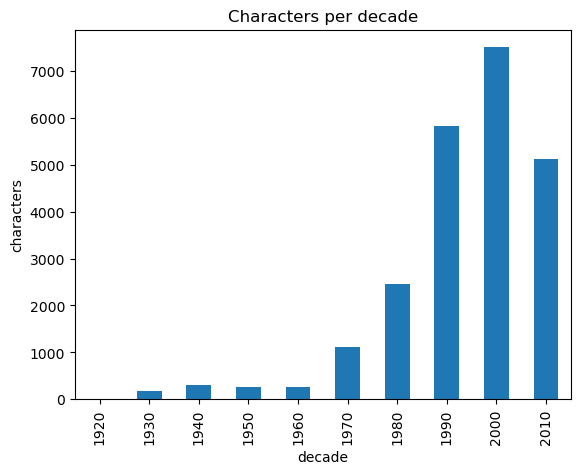

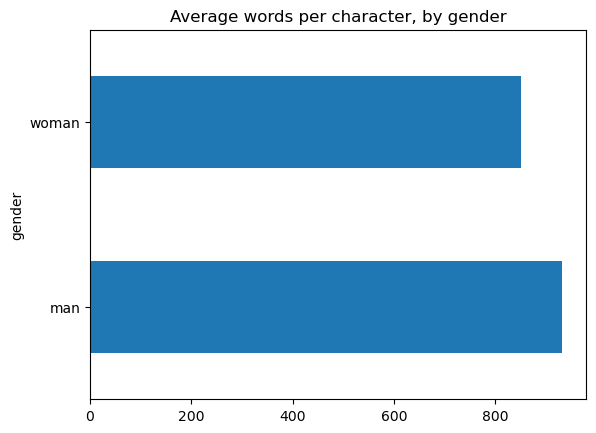

In [8]:
import matplotlib.pyplot as plt

df['decade'] = df['release_year'] // 10 * 10
df.groupby('decade').size().plot(kind='bar')
plt.title('Characters per decade')
plt.xlabel('decade')
plt.ylabel('characters')
plt.show()

df.groupby('gender')['words'].mean().plot(kind='barh')
plt.title('Average words per character, by gender')
plt.show()

## Extra exercises

### 9. Titles (standard)

String methods on a column: how many characters appear in a film whose title starts with *The* (`.str.startswith()`)? What is the longest title in the data (`.str.len()` and `.idxmax()`)? Make a column `title_words` with the number of words in the title (`.str.split().str.len()`) and show the average per decade.

In [9]:
print(df['title'].str.startswith('The ').sum())
print(df.loc[df['title'].str.len().idxmax(), 'title'])
df['title_words'] = df['title'].str.split().str.len()
print(df.groupby('decade')['title_words'].mean().round(2))

4472
The Chronicles of Narnia: The Lion, the Witch and the Wardrobe
decade
1920    2.00
1930    3.15
1940    3.48
1950    3.40
1960    2.27
1970    2.55
1980    2.81
1990    2.58
2000    2.61
2010    2.42
Name: title_words, dtype: float64


### 10. Age groups (standard)

Write a function `age_group(age)` that returns `'under 30'`, `'30-49'`, `'50 and over'`, or `'unknown'` when the age is missing (`pd.isna(age)` tests for a missing value). Apply it to the `age` column to make a column `age_group`, show how many characters fall in each group, and the average number of words per group. Which group speaks most?

In [10]:
def age_group(age):
    if pd.isna(age):
        return 'unknown'
    if age < 30:
        return 'under 30'
    if age < 50:
        return '30-49'
    return '50 and over'

df['age_group'] = df['age'].apply(age_group)
print(df['age_group'].value_counts())
print(df.groupby('age_group')['words'].mean().round(0))

age_group
30-49          9464
unknown        4782
50 and over    4633
under 30       4163
Name: count, dtype: int64
age_group
30-49          1130.0
50 and over     857.0
under 30       1081.0
unknown         367.0
Name: words, dtype: float64


### 11. Missing ages (standard)

Is the age missing more often for women than for men? Make a mask with `.isna()`, turn it into a column `age_missing`, and take its mean per gender. Then compute the average age per gender once on the full table and once on `df.dropna(subset=['age'])`: why are the results the same?

In [11]:
df['age_missing'] = df['age'].isna()
print(df.groupby('gender')['age_missing'].mean().round(3))
print(df.groupby('gender')['age'].mean().round(1))
print(df.dropna(subset=['age']).groupby('gender')['age'].mean().round(1))
# .mean() skips missing values anyway, so dropping the rows changes nothing for the average.

gender
man      0.209
woman    0.204
Name: age_missing, dtype: float64
gender
man      44.4
woman    37.4
Name: age, dtype: float64
gender
man      44.4
woman    37.4
Name: age, dtype: float64


### 12. Another file (standard)

The file `bikes.csv` counts cyclists per day on several bicycle paths in Montreal. It is separated by semicolons and encoded in `latin-1`. Load it with the right `sep` and `encoding` arguments, show its shape and column names, and print the total number of cyclists counted on the path *Berri 1* and the date with the highest count on that path.

In [12]:
bikes = pd.read_csv('../../data/bikes.csv', sep=';', encoding='latin-1')
print(bikes.shape)
print(list(bikes.columns))
print(bikes['Berri 1'].sum())
print(bikes.loc[bikes['Berri 1'].idxmax(), 'Date'])

(310, 10)
['Date', 'Berri 1', 'Brébeuf (données non disponibles)', 'Côte-Sainte-Catherine', 'Maisonneuve 1', 'Maisonneuve 2', 'du Parc', 'Pierre-Dupuy', 'Rachel1', 'St-Urbain (données non disponibles)']
925365
15/06/2012


### 13. From text to table (harder)

Read `alice.txt`, tokenise it with `re.findall(r'[a-z]+', text.lower())` and count the tokens with a `Counter`. Turn the counter into a DataFrame with the columns `word` and `count`, add a column `length`, and answer: the ten most frequent words of at least seven letters; the average length of the words that occur only once versus the words that occur at least ten times (group by a boolean column).

In [13]:
import re
from collections import Counter

with open('../../data/alice.txt', encoding='utf-8') as infile:
    text = infile.read()

counts = Counter(re.findall(r'[a-z]+', text.lower()))
words = pd.DataFrame(counts.items(), columns=['word', 'count'])
words['length'] = words['word'].str.len()

print(words[words['length'] >= 7].sort_values('count', ascending=False).head(10))

words['frequent'] = words['count'] >= 10
print(words[(words['count'] == 1) | words['frequent']].groupby('frequent')['length'].mean().round(2))

             word  count  length
670       herself     83       7
595       thought     74       7
2516      gryphon     55       7
1103      duchess     42       7
2167     dormouse     40       8
587       nothing     34       7
1334      looking     32       7
3         project     31       7
1388      replied     29       7
1779  caterpillar     28      11
frequent
False    6.73
True     4.57
Name: length, dtype: float64


### 14. Save a subset (harder)

Make a table of the lead characters (`is_lead`) of films released in 2015 with the columns `film`, `character`, `gender` and `words`, sorted by words from high to low, and save it as `output/leads_2015.csv` without the index (create the `output` folder first with `os.makedirs('output', exist_ok=True)`). Read the file back in and check that its shape is (94, 4).

In [14]:
leads_2015 = df[df['is_lead'] & (df['release_year'] == 2015)][['film', 'character', 'gender', 'words']].sort_values('words', ascending=False)
import os
os.makedirs('output', exist_ok=True)
leads_2015.to_csv('output/leads_2015.csv', index=False)

check = pd.read_csv('output/leads_2015.csv')
print(check.shape)
print(check.head(3))

(94, 4)
                                    film   character gender  words
0                      Steve Jobs (2015)  Steve Jobs    man  10443
1                             Joy (2015)         Joy  woman   5903
2  Me and Earl and the Dying Girl (2015)        Greg    man   5388


### 15. Dates (harder)

Dates in a CSV file are read as plain text unless you tell `pandas` otherwise. Load `bikes.csv` again with two extra arguments: `parse_dates=['Date']` turns that column into real dates, and `dayfirst=True` says that `01/02/2012` is the first of February, not the second of January. Check the type of the column with `.dtype`, and print the first and the last date (`.min()`, `.max()`). A date column has its own methods behind `.dt`: `bikes['Date'].dt.day_name()` gives the weekday as a word, `.dt.month` the month as a number. Add a column `Weekday`, and show the average number of cyclists on *Berri 1* per weekday, rounded to whole numbers. Which weekday is the busiest (Thursday, 3639)?

In [15]:
bikes = pd.read_csv('../../data/bikes.csv', sep=';', encoding='latin-1', parse_dates=['Date'], dayfirst=True)
print(bikes['Date'].dtype)
print(bikes['Date'].min(), bikes['Date'].max())

bikes['Weekday'] = bikes['Date'].dt.day_name()
per_weekday = bikes.groupby('Weekday')['Berri 1'].mean().round(0)
print(per_weekday.sort_values(ascending=False))

datetime64[ns]
2012-01-01 00:00:00 2012-11-05 00:00:00
Weekday
Thursday     3639.0
Wednesday    3477.0
Friday       3222.0
Tuesday      3075.0
Monday       2984.0
Saturday     2309.0
Sunday       2207.0
Name: Berri 1, dtype: float64


### 16. Cyclists over the year (harder)

With the `bikes` table from the previous exercise: add a column `Month` (`.dt.month`), sum the cyclists on *Berri 1* per month, and plot the result as a bar chart with a title. Then plot the daily counts on *Berri 1* as a **line** over time: `bikes.plot(x='Date', y='Berri 1')` draws one column against another (`kind='line'` is the default). What does the line show that the bar chart does not?

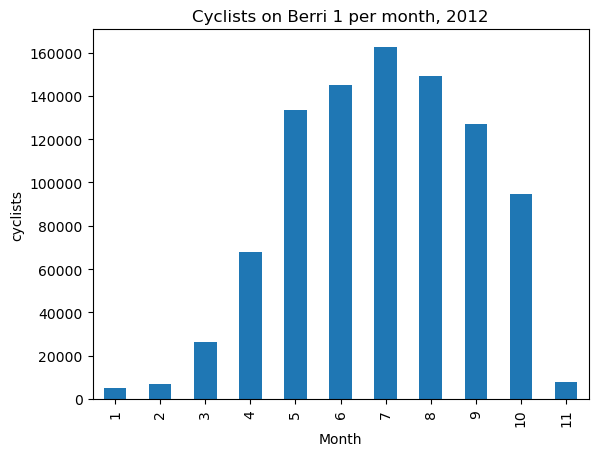

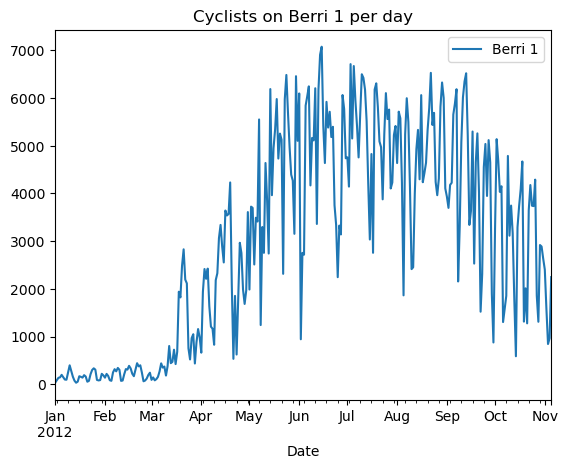

In [16]:
bikes['Month'] = bikes['Date'].dt.month
bikes.groupby('Month')['Berri 1'].sum().plot(kind='bar')
plt.title('Cyclists on Berri 1 per month, 2012')
plt.ylabel('cyclists')
plt.show()

bikes.plot(x='Date', y='Berri 1')
plt.title('Cyclists on Berri 1 per day')
plt.show()
# The line shows the day-to-day variation (the weekly rhythm, cold or rainy days) that the
# monthly totals average away.

### 17. Box and scatter, once more (harder)

Two plots like the ones in the session, on different columns. First a box plot of the actors' ages per *part* (add the column `part` with the function from the session: `'lead'` for at least 20% of the dialogue, `'supporting'` for at least 5%, `'minor'` otherwise), on the table without impossible ages. Then a scatter plot of `gross` against `release_year` with a small `alpha`. Give both a title and write in a comment what you see: are leads younger than minor characters, and do recent films gross more?

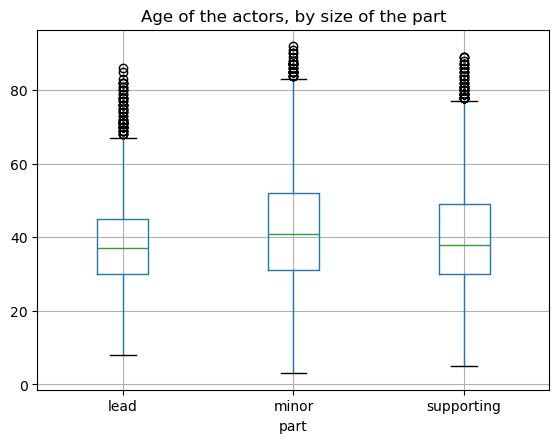

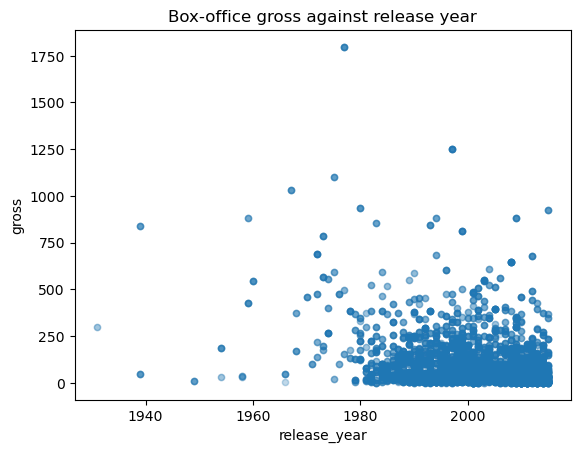

In [17]:
def part_size(proportion):
    if proportion >= 0.2:
        return 'lead'
    if proportion >= 0.05:
        return 'supporting'
    return 'minor'

df['part'] = df['proportion_of_dialogue'].apply(part_size)
clean = df[df['age'] < 100]

clean.boxplot(column='age', by='part')
plt.title('Age of the actors, by size of the part')
plt.suptitle('')
plt.show()

df.plot(kind='scatter', x='release_year', y='gross', alpha=0.1)
plt.title('Box-office gross against release year')
plt.show()
# Leads are cast younger than supporting and minor characters (the whole box sits lower).
# The gross is not higher for recent films; the very high values are spread over the decades,
# and the dense band of low grosses only gets denser because there are more recent films.

### 18. Exam style: who speaks in the movies (harder)

This exercise has the form of an exam question on a table: three steps of increasing difficulty.

(a) *Basic.* How many films and how many characters are in the data, and what is the average number of words per character, rounded to one decimal?

(b) *Intermediate.* Add a column `talkative` that is `True` for characters with more than 1,000 words. What share of the men and what share of the women are talkative (group by gender, mean of the column)?

(c) *Advanced.* Add a column `part` with the values `'lead'` (at least 20% of the dialogue), `'supporting'` (at least 5%) and `'minor'`, with a function and `.apply()`. Then compute the average age per gender *and* part with a two-column `groupby()`, on the table without impossible ages, and print for each part the average age of the women, of the men, and the difference, rounded to one decimal (loop over the three parts and read the values with `.loc[(gender, part)]`).

In [18]:
# (a)
print(df['script_id'].nunique())
print(len(df))
print(round(df['words'].mean(), 1))

# (b)
df['talkative'] = df['words'] > 1000
print(df.groupby('gender')['talkative'].mean().round(3))

# (c)
def part_size(proportion):
    if proportion >= 0.2:
        return 'lead'
    if proportion >= 0.05:
        return 'supporting'
    return 'minor'

df['part'] = df['proportion_of_dialogue'].apply(part_size)
clean = df[df['age'] < 100]
ages = clean.groupby(['gender', 'part'])['age'].mean()
for part in ['lead', 'supporting', 'minor']:
    women = ages.loc[('woman', part)]
    men = ages.loc[('man', part)]
    print(f'{part}: women {women:.1f}, men {men:.1f}, difference {men - women:.1f}')

2000
23042
908.0
gender
man      0.247
woman    0.244
Name: talkative, dtype: float64
lead: women 33.1, men 40.1, difference 7.0
supporting: women 35.1, men 42.3, difference 7.2
minor: women 37.6, men 43.8, difference 6.2


## Class exercises from the session notebook

Solutions to the exercises that are solved together during the session, for reference afterwards.

**Filters.** Women; women with more than 5,000 words; the characters of Titanic (1997).

In [19]:
import pandas as pd

df = pd.read_csv('../../data/screenplays.csv')

print(len(df[df['gender'] == 'woman']))
print(len(df[(df['gender'] == 'woman') & (df['words'] > 5000)]))
print(df[df['title'] == 'Titanic'][['character', 'title', 'words']].sort_values('words', ascending=False))

6911
114
             character    title  words
5428   Rose Dewitt Buk  Titanic   2792
20817      Jack Dawson  Titanic   2607
18672  Caledon 'Cal' H  Titanic   1210
528       Brock Lovett  Titanic   1062
10946     Lewis Bodine  Titanic    649
8833          Old Rose  Titanic    641
17494   Thomas Andrews  Titanic    559
5397   Ruth Dewitt Buk  Titanic    502
10846      Molly Brown  Titanic    474
1287    Spicer Lovejoy  Titanic    287
7321       Bruce Ismay  Titanic    286
3324   Captain Edward   Titanic    252
1790          Fabrizio  Titanic    189
13735       Tommy Ryan  Titanic    166
14888    Lizzy Calvert  Titanic    158
14958  Scotland Road S  Titanic    154
11832  2Nd Officer Lig  Titanic    153
19577     Father Byles  Titanic    149
6520             Woman  Titanic    116
19135  Col. Archibald   Titanic    102


**Groups.** Average age per gender; characters per year 2010-2015; the film with the most characters.

In [20]:
print(df[df['age'] < 100].groupby('gender')['age'].mean().round(1))
print(df.groupby('release_year').size().loc[2010:2015])
print(df.groupby('title').size().idxmax())

gender
man      42.7
woman    36.0
Name: age, dtype: float64
release_year
2010    978
2011    996
2012    818
2013    787
2014    889
2015    652
dtype: int64
Lone Star


**From text to table.** The ten most frequent words of more than six letters in Alice.

In [21]:
import re
from collections import Counter

with open('../../data/alice.txt', encoding='utf-8') as infile:
    text = infile.read()

counts = Counter(re.findall(r'[a-z]+', text.lower()))
words = pd.DataFrame(counts.items(), columns=['word', 'count'])
words['length'] = words['word'].str.len()
print(words[words['length'] > 6].sort_values('count', ascending=False).head(10))

             word  count  length
670       herself     83       7
595       thought     74       7
2516      gryphon     55       7
1103      duchess     42       7
2167     dormouse     40       8
587       nothing     34       7
1334      looking     32       7
3         project     31       7
1388      replied     29       7
1779  caterpillar     28      11
